# 3. Modelo SARIMA
El modelo SARIMA (Seasonal ARIMA) es una extensión del modelo ARIMA el cual incorpora explícitamente la componente de estacionalidad. Se expresa como:

SARIMA(p,d,q)(P,D,Q,s)

donde:

(p,d,q) representan los componentes no estacionales y (P,D,Q) representan los componentes estacionales.

s indica el periodo de la estacionalidad (por ejemplo, 24 para datos horarios diarios).

Este modelo resulta especialmente adecuado para el mercado eléctrico, ya que el precio de la electricidad presenta patrones periódicos claros, como la variación diaria de la demanda y los ciclos semanales.

### Como determinar (P,D,Q,s)

1. s 

    Esto es lo primero y más importante.

    Diario s = 24, Semanal s = 168

    Empiezamos con s = 24 (estacionalidad diaria)
    Luego probar con 168 a ver si hay mejora

2. D

    Aunque la serie es estacionaria en media (test ADF ok), puede no ser estacionaria estacionalmente.
    Qué hacer:

    Diferencia estacional, hacemos una diferenciacion con estacionalidad s

    Si p-valor < 0.05 entonces D = 1, sino D = 2 (mas raro)


2. P y Q

    Miramos ACF y PACF de la serie con diferenciación estacional:

    Nos fijamos en múltiplos de s (24, 48, 72...)

    * Para P (AR estacional)

    PACF en lags estacionales:

    Corte en lag 24  P = 1

    Corte en 24 y 48  P = 2

    * Para Q (MA estacional)

    ACF en lags estacionales:

    Pico en lag 24  Q = 1

    Pico en 24 y 48  Q = 2


Justificacion para la memoria:

Se identificó una estacionalidad clara de periodo 24 horas mediante el análisis de la ACF. Para eliminar esta componente se aplicó una diferenciación estacional (D=1). Posteriormente, los parámetros estacionales P y Q se determinaron observando los picos en los retardos múltiplos de 24 en las funciones PACF y ACF, respectivamente.


### Ejemplo código python:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from statsmodels.tsa.sarima.model import SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox



# ------------------------------
# 1. Cargar los datos
# ------------------------------
df = pd.read_csv('limpiezaPrecio3_Omie2020_2024.csv', sep=";")

# Ver las primeras filas
print(df.columns.tolist())
# ------------------------------
# 2. Preparar la serie temporal
# ------------------------------
# Convertir la columna de datetime a tipo datetime y ponerla como indice
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Ordenar por fecha por si acaso
df.sort_index(inplace=True)


# Seleccionamos la columna de precio (la que queremos predecir)
#serie = df['price']   # precio podria contener valores nulos, por si acaso
serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna() #quitamos valores erroneos

# Comprobar si hay fechas u horas repetidas
print("¿Hay duplicados en el índice?", serie.index.duplicated().any())

duplicados = serie.index[serie.index.duplicated(keep=False)].unique()
print("Índices duplicados:", duplicados[:10])  # muestra los primeros 10 repetdos
# Asigna frecuencia, para nosostros h para una frecuencia en horas
serie = serie.asfreq('h')   # o 'd' para dias

['datetime', 'price', 'hour']
¿Hay duplicados en el índice? False
Índices duplicados: DatetimeIndex([], dtype='datetime64[us]', name='datetime', freq=None)


### Averiguamos D

Aunque la serie es estacionaria en media (ADF ok), puede no ser estacionaria estacionalmente.
Qué hacer:

Diferencia estacional. Si p-valor < 0.05 entonces D = 1, sino D = 2 (mas raro)

Justificacion para la memoria:
Se identificó una estacionalidad clara de periodo 24 horas mediante el análisis de la ACF. Para eliminar esta componente se aplicó una diferenciación estacional (D=1)

In [ ]:
serie_seasonal_diff = serie.diff(24).dropna()
D = 0
if adfuller(serie_seasonal_diff)[1] < 0.05: ## p-valor para la prueba de estacionariedad
    D = 1
    print("D = 1")
else:
    D = 2
    print("D = 2")
print(adfuller(serie_seasonal_diff)[1])  

0.0


### Averiguamos P y Q

|Modelo Estacional |ACF lags 24, 48,... |PACF lags 24, 48,...|
|:-----|:-----|:-----
|MA(Q) (solo Q) | Se corta después del lag 24*Q (picos significativos hasta 24Q) | Decae gradualmente (exponencial o sinusoidal)
|AR(P) (solo P) | Decae gradualmente | Se corta después del lag 24*P
|ARMA(P, Q)     | Decae gradualmente | Decae gradualmente

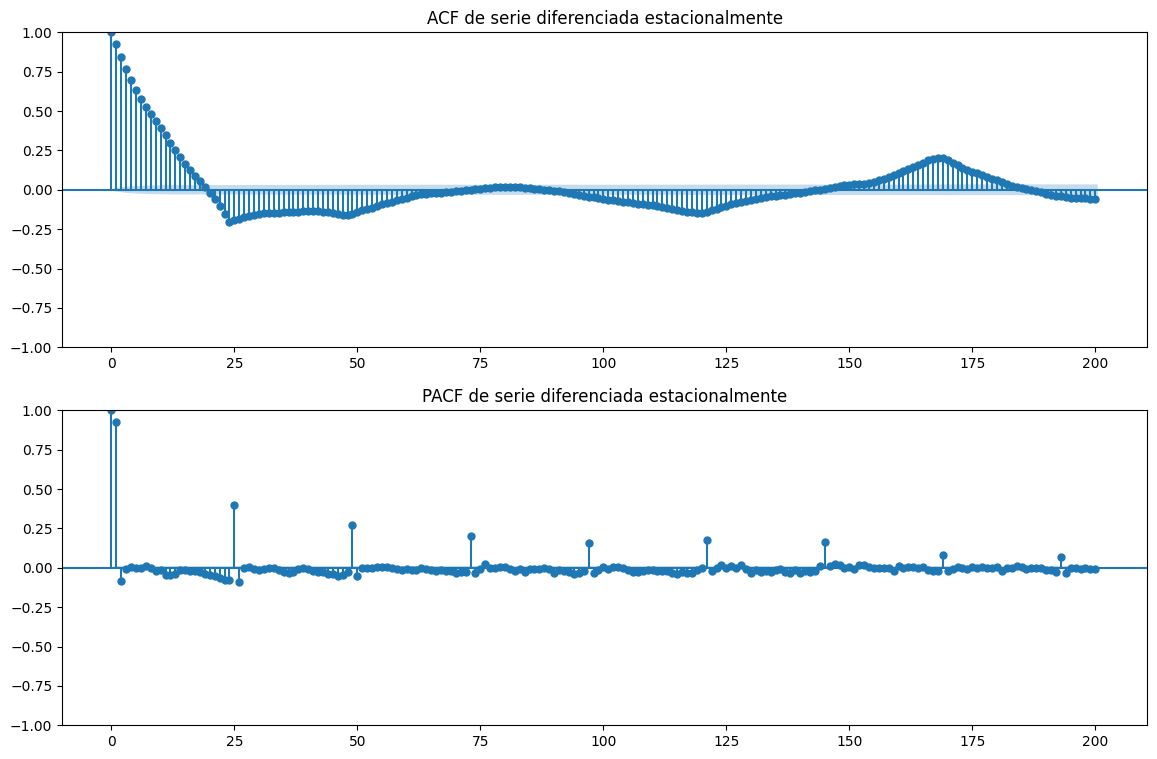

In [15]:
# Gráfico ACF de serie diferenciada estacionalmente
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
plot_acf(serie_seasonal_diff, ax=axes[0], lags=200)
axes[0].set_title('ACF de serie diferenciada estacionalmente')

plot_pacf(serie_seasonal_diff, ax=axes[1], lags=200)
axes[1].set_title('PACF de serie diferenciada estacionalmente')

plt.savefig('sarima_acf_pacf_seasonal_diff.png', dpi=150, bbox_inches='tight')
plt.show()


#plot_acf(serie_seasonal_diff, lags=200)
#plot_pacf(serie_seasonal_diff, lags=200)

Resumen de las funciones ACF PACF, escribir esto tal cual en la memoria:

* ACF: No se corta bruscamente después de lag 24 (porque lag 48 = -0.20, similar a -0.25). Además, sigue con valores pequeños hasta lag 168, donde reaparece un 0.22 (podría ser ruido o un segundo patrón). Esto indica decaimiento gradual (aunque con signo negativo y luego positivo). → No es un MA puro (que habría cortado).

* PACF: Tiene picos significativos en 24, 48, … que decrecen gradualmente (0.5, luego menor, luego 0.12). Esto es decaimiento gradual, no un corte brusco. → No es un AR puro (que habría cortado después de lag 24).

La combinación de ACF con decaimiento y PACF con decaimiento apunta a un modelo mixto estacional ARMA(P, Q) con P ≥ 1 y Q ≥ 1

Dado que los valores son pequeños y típicamente se empieza con los órdenes más bajos posibles, la opción más razonable es:

P = 1, Q = 1 (un ARMA estacional de primer orden).

¿Por qué no P=0, Q=2? Porque el ACF no muestra un corte claro después de lag 48 (el valor en lag 48 sigue siendo ≈ -0.20, comparable al de lag 24). Para un MA(2) estacional puro, el ACF debería tener picos significativos en lags 24 y 48, y luego cortarse a cero (o no significativo) en lag 72. Los datos muestran que lag 48 sigue siendo relevante, pero no hay un corte brusco. Además, la PACF con decaimiento es consistente con MA(2), pero el ACF no es el de un MA(2) puro.

¿Por qué no P=1, Q=0? Porque la PACF no se corta después de lag 24, tiene múltiples picos decrecientes, lo cual es incompatible con un AR(1) puro (que tendría un único pico en lag 24 y luego PACF ≈ 0).

Por tanto, P=1 y Q=1 es la combinación incial que mejor explica ambas gráficas.

Ojo pico en ACF en lag 168 (1semana):

El valor de ACF ≈ 0.22 en lag 168 (7×24) es moderado. Dependiendo del tamaño de la muestra, podría ser significativo o no. Si es significativo, indica estacionalidad semanal adicional (ciclo de 7 días en datos horarios). En ese caso, un único componente estacional con s=24 no será suficiente. Necesitaría:

* Un modelo SARIMA con doble estacionalidad, ej: SARIMA(2,0,1)(1,1,1)[24](0,0,1)[168]

* Probar a diferenciar también con s=168

Tamaño entrenamiento: 39848 horas (1660 días)
Tamaño prueba:        4000 horas  (167 días)
Porcentaje test:      9.1%
                                      SARIMAX Results                                      
Dep. Variable:                               price   No. Observations:                39848
Model:             SARIMAX(2, 1, 1)x(2, 1, [], 24)   Log Likelihood             -145410.028
Date:                             Fri, 08 May 2026   AIC                         290832.055
Time:                                     10:51:35   BIC                         290883.601
Sample:                                 01-01-2020   HQIC                        290848.375
                                      - 07-18-2024                                         
Covariance Type:                            approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

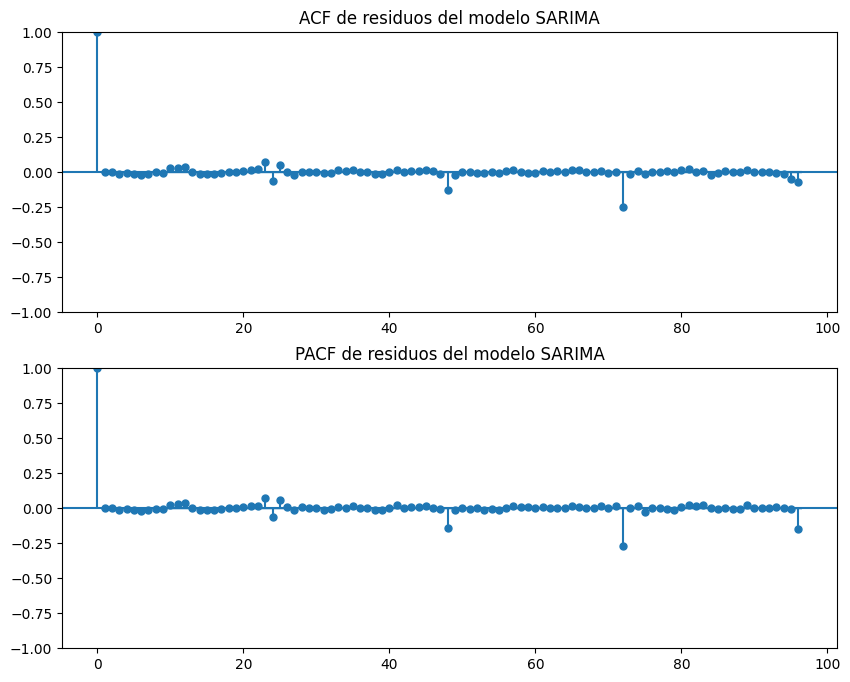


TEST LJUNG-BOX
      lb_stat     lb_pvalue
10  70.106537  4.228657e-11
los residuos NO son ruido blanco (tienen estructura/autocorrelacion)

========== MÉTRICAS DE PRECISIÓN ==========
  MAE   (Error Absoluto Medio):        29.4426 €/MWh
  RMSE  (Raíz Error Cuadrático Medio): 37.8595 €/MWh
  MAPE  (Error Porcentual Medio):       666882909251826688.00%
  R²    (Coeficiente determinación):    0.1849
  RMSE modelo naive (benchmark):        13.9340 €/MWh
  El modelo es PEOR que el naive



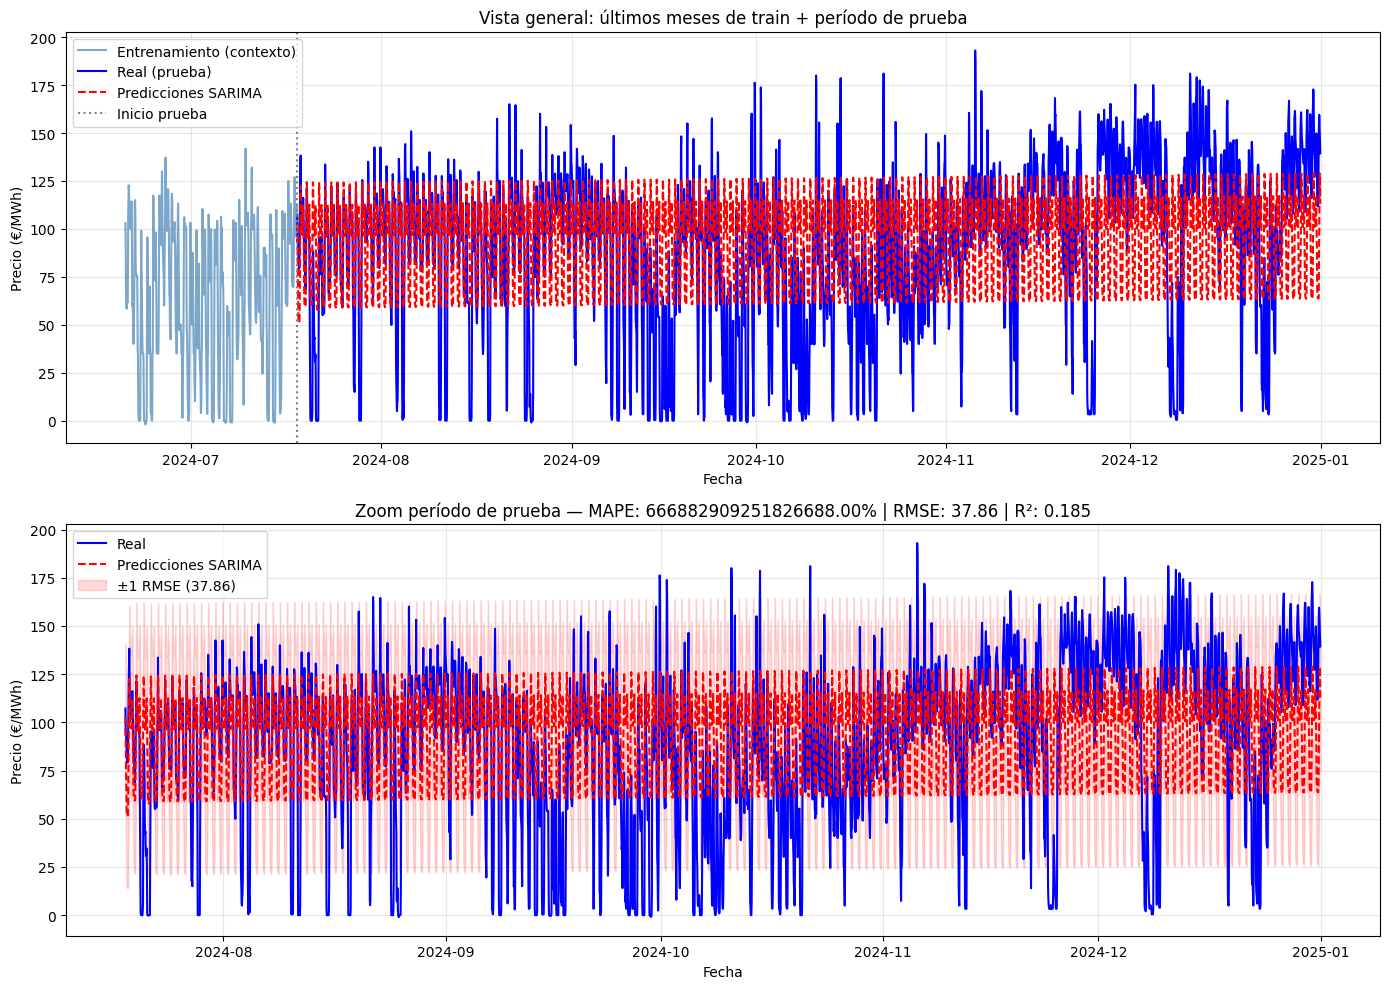

In [17]:
# ==============================
# 4. División en entrenamiento y prueba
# ==============================
# ultimos meses del dataset (4000 horas) para test, mas representativo
TEST_HOURS = 4000  # Ultimos meses

train = serie[:-TEST_HOURS]
test  = serie[-TEST_HOURS:]

print(f"Tamaño entrenamiento: {len(train)} horas ({len(train)/24:.0f} días)")
print(f"Tamaño prueba:        {len(test)} horas  ({len(test)/24:.0f} días)")
print(f"Porcentaje test:      {100*len(test)/len(serie):.1f}%")

# ==============================
# 5. Elegir los órdenes p y q del modelo SARIMA
# ==============================
# En Box-Jenkins a partir de los gráficos de ACF y PACF, elegimos p y q
# En nuestro caso fueron p=2 y q=1
# En ARIMA, el orden es (p, d, q).
# El valor d e sel numero de diferenciaciones para hacer la serie estacionaria,
#  pero como la serie ya es estacionaria, no es necesario diferenciar (d=0)
#  aunque se puede poner d=1 sin que cambie el resultado matemático porque
#  ARIMA con d=1 en una serie ya estacionaria es equivalente a ARMA con d=0
p, d, q = 2, 1, 1           # parte no estacional (igual que ARIMA/ARMA)
P, D, Q, s = 2, 1, 0, 24    # parte estacional 


modelo_sarima = SARIMAX(
    train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Ajustar el modelo
modelo_ajustado = modelo_sarima.fit(low_memory=True)  # Reduce uso de memoria

# Mostrar un resumen del modelo
print(modelo_ajustado.summary())


# ==============================
# 5.2. Verificar residuos (validación)
# ==============================

# Verificar residuos (validación)
residuos = modelo_ajustado.resid

# Gráfico ACF de residuos
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(residuos, ax=axes[0], lags=96)
axes[0].set_title('ACF de residuos del modelo SARIMA')

plot_pacf(residuos, ax=axes[1], lags=96)
axes[1].set_title('PACF de residuos del modelo SARIMA')
plt.savefig('sarima_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# Prueba de Ljung-Box (si p-value > 0.05 los residuos son ruido blanco)
lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(f"\nTEST LJUNG-BOX")
print(lb_test.to_string())
if (lb_test['lb_pvalue'] > 0.05).all():
    print("los residuos son ruido blanco")
else:
    print("los residuos NO son ruido blanco (tienen estructura/autocorrelacion)")

# ==============================
# 6. Predecir los valores del conjunto de prueba
# ==============================
# forecast recibe el número de pasos a predecir
predicciones = modelo_ajustado.forecast(steps=len(test))
predicciones.index = test.index   # para que luego se pueda gaficar bien

# ==============================
# 7. AMPLIADA - Métricas de precisión
# ==============================
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae  = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = mean_absolute_percentage_error(test, predicciones) * 100

# Métrica adicional: R² (qué % de varianza explica el modelo)
ss_res = np.sum((test - predicciones) ** 2)
ss_tot = np.sum((test - test.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Naive benchmark: predecir siempre el valor anterior (lag-1)
naive_pred = test.shift(1).dropna()
rmse_naive = np.sqrt(mean_squared_error(test[1:], naive_pred))

print("\n========== MÉTRICAS DE PRECISIÓN ==========")
print(f"  MAE   (Error Absoluto Medio):        {mae:.4f} €/MWh")
print(f"  RMSE  (Raíz Error Cuadrático Medio): {rmse:.4f} €/MWh")
print(f"  MAPE  (Error Porcentual Medio):       {mape:.2f}%")
print(f"  R²    (Coeficiente determinación):    {r2:.4f}")
print(f"  RMSE modelo naive (benchmark):        {rmse_naive:.4f} €/MWh")
print(f"  El modelo es {'MEJOR' if rmse < rmse_naive else 'PEOR'} que el naive")
print("============================================\n")


# ==============================
# 8. CORREGIDA - Gráficas con zoom y separadas
# ==============================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfica 1: visión global (últimas 4 semanas de train + todo el test) ---
CONTEXTO = 672  # horas de entrenamiento que se muestran como contexto

ax1 = axes[0]
ax1.plot(train[-CONTEXTO:].index, train[-CONTEXTO:],
         label='Entrenamiento (contexto)', color='steelblue', alpha=0.7)
ax1.plot(test.index, test,
         label='Real (prueba)', color='blue', linewidth=1.5)
ax1.plot(test.index, predicciones,
         label='Predicciones SARIMA', color='red', linestyle='--', linewidth=1.5)
ax1.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1.5,
            label='Inicio prueba')
ax1.set_title('Vista general: últimos meses de train + período de prueba')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio (€/MWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: zoom solo en el período de prueba ---
ax2 = axes[1]
ax2.plot(test.index, test,
         label='Real', color='blue', linewidth=1.5)
ax2.plot(test.index, predicciones,
         label='Predicciones SARIMA', color='red', linestyle='--', linewidth=1.5)
ax2.fill_between(test.index,
                 predicciones - rmse,
                 predicciones + rmse,
                 alpha=0.15, color='red', label=f'±1 RMSE ({rmse:.2f})')
ax2.set_title(f'Zoom período de prueba — MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | R²: {r2:.3f}')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Precio (€/MWh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sarima_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()